# Simulation playground

This notebook is just for figuring out the simulation workflow for the artificial network simulations, playing with parameters etc.

In [1]:
# library imports
import numpy as np   
import matplotlib.pyplot as plt
import networkx as nx
import random
import EoN

import immunization_funcs as imf # this is where the immunization strategies are implemented, see immunization_funcs.py

The parameters we want to vary/investigate are:
- Network structure:
    - Modularity $Q$ (0.76...0.975)
    - (maybe also number/size of communities? problem for later though)
- Immunization: 
    - algorithms (None, Random, degree-based, ACQ, CBF, BHD, BNI-LI) 
    - immunization coverage (0.01-0.3)
- SIR simulation: 
    - transmission rate $\beta$ (BHD paper uses 0.08)
    - recovery rate $\gamma$ (BHD paper & CBF paper use 0.2)
    - or just vary $R_0 = \langle k \rangle \cdot \frac{\beta}{\gamma} = 10 \cdot \frac{\beta}{\gamma}$ with the current network setup -> maybe let's aim for 1...10?? If we fix $\gamma = 0.2$, then $R_0 = 50\cdot \beta$ -> use $\beta$=0.02...0.2?

For the SIR part, it might be worth experimenting with different combinations of $\beta$ and $\gamma$ that yield the same ratio $R_0$, just to see if the individual settings matter or if just $R_0$ matters.

Values we want to collect to characterise the results of the epidemic simulations:
- final epidemic ratio $R$ (the fraction of the population ever infected at the end of the epidemic)(in our lectures: final attack rate)
- peak prevalence $I_m$ (the highest density of infected nodes in the population at a time during the epidemic)
- avg. epidemic duration $T_{avg}$


### Artificial Network Generation:
Using the strategy from the Salathé-Jones paper (the CBF paper):
- create 50 small-world communities of $N=40$ nodes via Watts-Strogatz, each node has exactly 8 
edges connecting to nodes of the same community
- add 2000 edges randomly between randomly chosen nodes between communities
- -> graph with 2000 nodes and 10000 (i.e. (2000+50 * 40 * (8/2))) undirected edges where one out of five edges falls between communities.
- increase community structure by rewiring between-community edges so that they become within-community edges: at each step
    - randomly choose a between-community edge,
    - randomly choose one of the two communities that the edge connects, 
    - pick a random node of the chosen community, 
    - rewire the edge by detaching it from the node of the community that was not chosen in step 2, and attaching it to the new node in the community that was chosen in step 3

In [2]:
def generate_community_network(m = 50, n_sw=40, rewire_steps=0, verbose=False):
    n_tot = m*n_sw # total number of nodes in the graph
    k = int(0.2*n_sw) # number of inter-community edges per node
    sw_graphs = [nx.watts_strogatz_graph(n_sw, k=k, p=0.0) for _ in range(m)]    
    # create list of community labels for each node
    communities_partition = [{i*n_sw + j for j in range(n_sw)} for i in range(m)]  # sets of nodes
    G = nx.disjoint_union_all(sw_graphs)
    # add n_tot random inter-community edges
    added_edges = 0
    while added_edges < n_tot:
        c1, c2 = np.random.choice(m, size=2, replace=False) # get 2 random communities
        n1 = np.random.choice(n_sw) + c1*n_sw # get a random node from community 1
        n2 = np.random.choice(n_sw) + c2*n_sw # get a random node from community 2
        if not G.has_edge(n1, n2): # avoid multi-edges
            G.add_edge(n1, n2) # add an inter-community edge
            added_edges += 1
    # compute modularity
    if verbose:
        print("Modularity before rewiring:", nx.algorithms.community.quality.modularity(G, communities_partition))
        print("Average degree:", np.mean([d for n, d in G.degree()]))
    # rewire random between-community edges to within-community edges, to increase modularity
    betw_edges = set((u, v) for u, v in G.edges() if u // n_sw != v // n_sw)
    rewired = 0
    while rewired < rewire_steps:
        if not betw_edges:
            break
        # pick a random between-community edge
        edge = random.choice(list(betw_edges))    # pick a random endpoint to keep (u or v), and rewire the other one
        u, v = edge
        if np.random.rand() < 0.5:
            u, v = v, u # swap so that u is the one we keep
        # rewire v to a random node in the same community as u
        community = u // n_sw
        new_v = np.random.choice(n_sw) + community*n_sw
        # only add the new edge if it doesn't already exist, to avoid creating multi-edges
        # and also avoid self-loops
        if new_v != u and not G.has_edge(u, new_v):
            G.remove_edge(*edge)
            betw_edges.discard(edge)
            G.add_edge(u, new_v)
            rewired += 1

    modularity_final = nx.algorithms.community.quality.modularity(G, communities_partition)
    if verbose:
        print("Modularity after rewiring:", modularity_final)

    return G, communities_partition, modularity_final

The modularity depends linearly on the number of rewiring steps. If we stick with the original paper's values: $m=50$ communities of $n_{sw} = 40$ nodes each, the modularity ranges from 0 steps -> $Q \approx 0.78$ to 2000 steps -> $Q \approx 0.975$, slope $\approx 0.0001$. The average degree is $\langle k\rangle = 10$.

### Simulation workflow

We initially agreed on 300 repetitions per configuration, but I kinda forgot that every single part introduces some stochasticity and I'm not sure how much sense it makes to split this? Since we have  randomized network generation, at least for some methods random immunization, and for sure the stochasticity of the SIR simulation. So it might be nice to investigate the random fluctuations at each stage of the process to better adjust that. But generally, the idea is:
- *Network generation*: 
    - set up e.g. $n_{nw}=10$ network instances for each modularity value (let's do it in 100 rewiring step intervals -> 21 modularity values)?
- *Immunization*:
    - do one baseline (no immunization)
    - for each of the 6 algorithms (Random, degree-based, ACQ, CBF, BHD, BNI-LI), do maybe 10 immunization coverage steps from ~0.01..0.3?
    - let's not repeat that, for now
- *SIR simulation*
    - assuming we don't change $\gamma$ seperately, I'd go with $n_{rep} = 100$ repetitions here for each of the 10 $\beta$ values from 0.02 - 0.2?

This would yield a total of $10\cdot21=210$ network configurations, times $6\cdot 10 +1=61$ immunization trials, times $100\cdot 10 = 1000$ SIR simulations, yielding $210\cdot 61 \cdot 1000 = 12\,810\,000$ simulations. Hooo boy. That won't work out for sure, guess we gotta focus on varying this one at a time...


Alternatively:
- **Investigating Network modularity impact**: fix immunization coverage of e.g. $f=0.1$, and SIR simulation parameters to e.g. BHD values ($\beta = 0.08$, $\gamma = 0.2$) and do the simulations for the 21 modularity values, with 10 realizations each, for each of the 6 algorithms, with 100 SIR repetitions, yielding $21 \cdot 10 \cdot 6 \cdot 100 = 126\,000$
- **Investigating immunization coverage impact**: based on modularity results, pick maybe 2-3 modularity values, no network reps, the same fixed SIR values, and try 10-15 different immunization coverage settings for each of the 6 algorithms (+1 without immunization), and 100 SIR reps yielding roughly $3 \cdot (10 \cdot 6 + 1) \cdot 100 = 18\,300$
- **Investigating SIR params impact**: 2-3 modularity values, no network reps, fixed immunization coverage, for each of the 6 algorithms testing 10 different $\beta$ values with 100 SIR repetitions each yields $3 \dot (6 + 1) \cdot 10 \cdot 100 = 21\,000$

total: $165\,300$ simulations - more manageable ig?



In [3]:
# -------- Network params ---------
n_sw = 40 # number of nodes within each small-world community
m = 50 # number of communities
nw_reps = 10 # number of repetitions for each network config
rewire_steps = 1000

# -------- Immunization params ----
immunization_funcs = {  # dict of immunization functions
    'Random': imf.random_immunization,
    'Degree': imf.degree_immunization,
    'ACQ': imf.ACQ,
    'CBF': imf.cbf_immunization,
    'BHD': imf.BHD,
    'BNI-LI': imf.BNI_LI} 
immunization_coverage = 0.1 # fraction of nodes to immunize

# -------- SIR params -------------
sir_reps = 100 # number of repetitions for SIR simulations
beta = 0.08 # transmission rate
gamma = 0.2 # recovery rate
tmax = 200 # maximum number of timesteps for SIR simulation


In [ ]:
# set up one full simulation run
# this will go into a neat little function later
# but for testing purposes, let's just do it 

# --- NETWORK GENERATION ---
G, communities_partition, modularity_final = generate_community_network(
    m=m, n_sw=n_sw, rewire_steps=rewire_steps, verbose=True)

# --- IMMUNIZATION ---
immunization_results = {}
for key, func in immunization_funcs.items():
    immunized_nodes = func(G, coverage=immunization_coverage)
    immunization_results[key] = immunized_nodes

# check that all methods yield the same number of immunized nodes
n_immunized = int(immunization_coverage*G.number_of_nodes())  
for key, l in immunization_results.items():
    if len(l) != n_immunized:
        print(f"{key} yielded {len(l)} nodes, when target was {n_immunized}.")

# --- SIR SIMULATION ---
sir_results = {} 
for key, immunized_nodes in immunization_results.items():
    sir_res = []
    for _ in range(sir_reps):
        res = EoN.fast_SIR(G, beta, gamma, tmax=tmax, initial_recovereds=immunized_nodes, return_full_data = True)
        sir_res.append(res)
    sir_results[key] = sir_res

# --- WRITE RESULTS TO FILE
# right now, let's just stupidly save the result dict as txt
# later, we should for sure figure out a more efficient way of storing things
# also, we're going to have to make a proper header later
# welp, this will be fun
with open('data.txt', 'w') as file:
    file.write(str(sir_results))


Modularity before rewiring: 0.7799899600000004
Average degree: 10.0
Modularity after rewiring: 0.8799860599999999


Random results:
Avg. peak prevalence: 224.01
Avg. final epidemic ratio: 0.5252649999999999
Avg. epidemic duration: 56.72817946255963


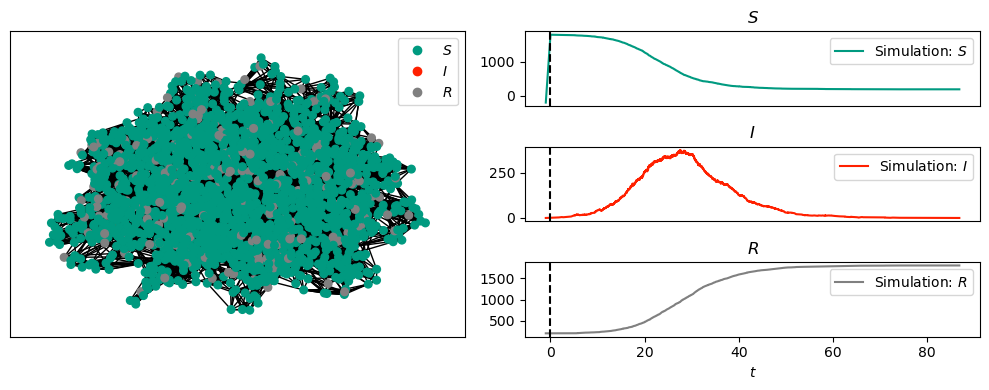

Degree results:
Avg. peak prevalence: 123.25
Avg. final epidemic ratio: 0.409885
Avg. epidemic duration: 66.90073512697097


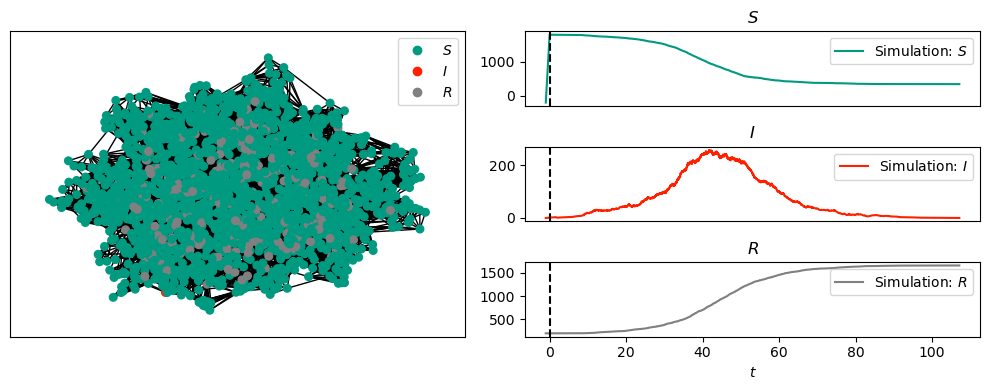

ACQ results:
Avg. peak prevalence: 182.76
Avg. final epidemic ratio: 0.455165
Avg. epidemic duration: 52.25881324910967


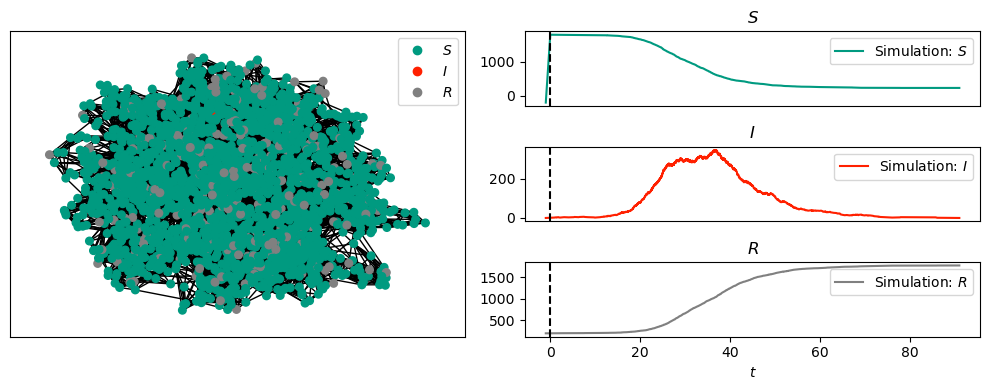

CBF results:
Avg. peak prevalence: 205.6
Avg. final epidemic ratio: 0.4693850000000001
Avg. epidemic duration: 50.64610818817666


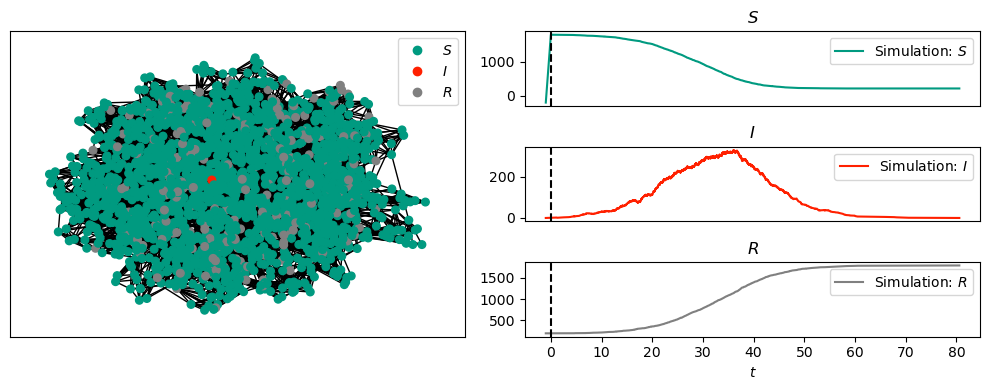

BHD results:
Avg. peak prevalence: 208.16
Avg. final epidemic ratio: 0.495435
Avg. epidemic duration: 55.94714612853063


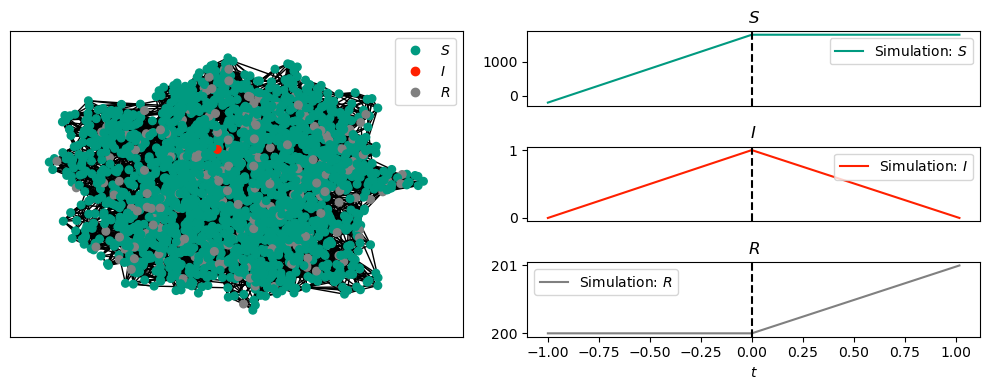

BNI-LI results:
Avg. peak prevalence: 188.66
Avg. final epidemic ratio: 0.424075
Avg. epidemic duration: 45.29695145240784


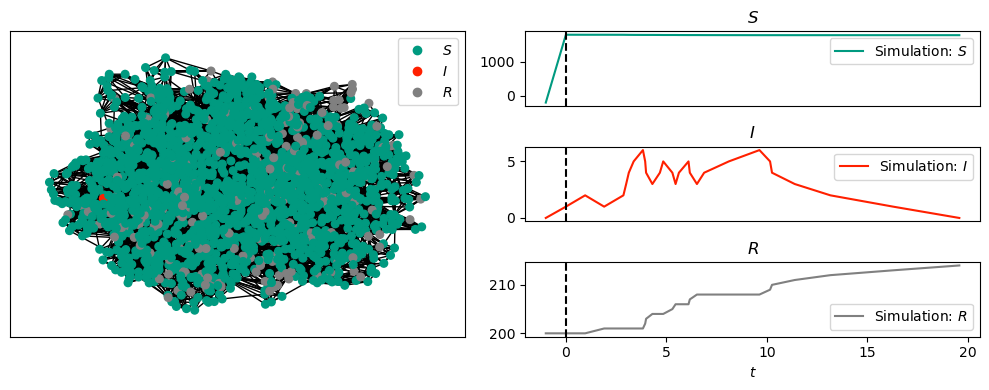

In [8]:
# let's check the results
# at least for one of the simulations per algorithm
for key, res in sir_results.items():
    print(f"{key} results:")
    # get peak prevalence
    peak_prevalences = [max(result.I()) for result in res]
    print(f"Avg. peak prevalence: {np.array(peak_prevalences).mean()}")

    # get final epidemic ratio
    ratios = []
    for r in res:
        ratio = 0.0
        for n in G.nodes():
            wasInfected = int('I' in r.node_history(n)[1])
            ratio += wasInfected
        ratios.append(ratio/2000)
    print(f"Avg. final epidemic ratio: {np.array(ratios).mean()}")

    # get epidemic duration
    epidemic_durations = [max(result.t()) for result in res]
    print(f"Avg. epidemic duration: {np.array(epidemic_durations).mean()}")

    # plot initial state
    res[0].display(0, node_size=30) 
    plt.show()

DOES THE FINAL EPIDEMIC RATIO THINGY ACCIDENTALLY COUNT THE IMMUNIZED NODES TOO???? INVESTIGATE T.T